In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import comb
import os

In [2]:
FIG_DIR= "figures"
os.makedirs(FIG_DIR, exist_ok=True)

In [3]:
np.random.seed(0)

## Return probabilities

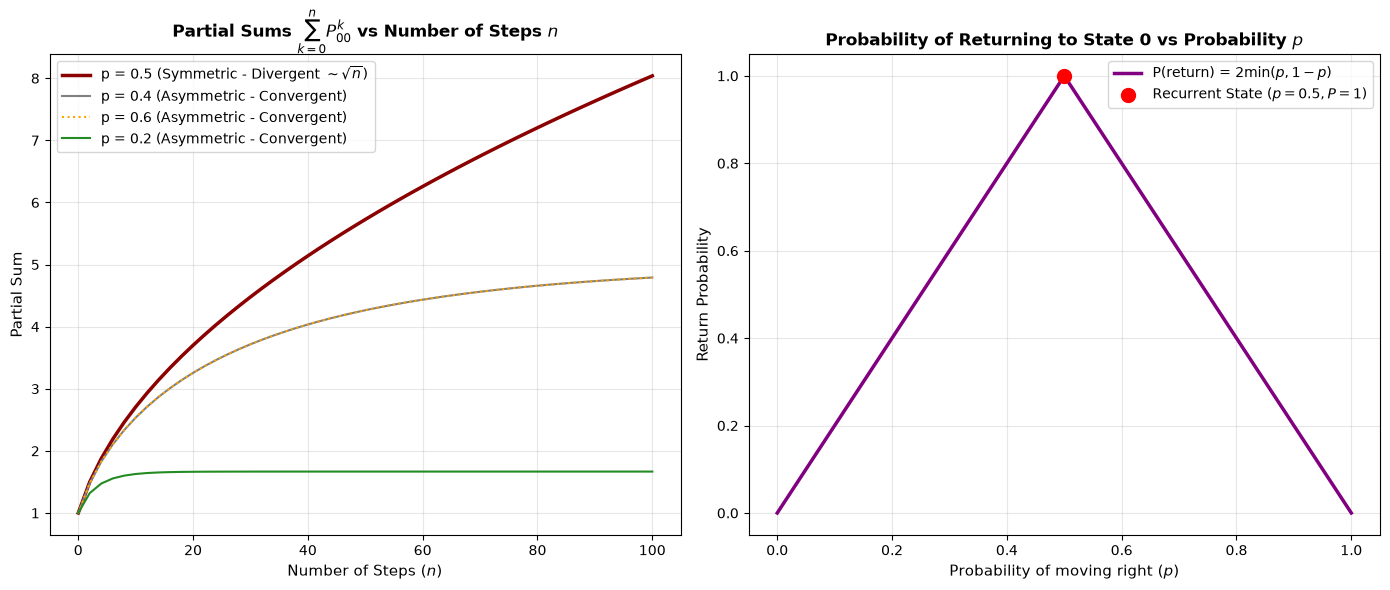

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

max_n = 100  # Maximum number of steps (even numbers only, as return is only possible in even steps)
n_steps = np.arange(0, max_n + 1, 2)

def calculate_partial_sums(p, steps):
    p_00 = []
    for n in steps:
        if n == 0:
            p_00.append(1.0)
        else:
            # P_{00}^{2k} = (2k choose k) * p^k * (1-p)^k
            k = n // 2
            p_n = comb(n, k) * (p**k) * ((1 - p)**k)
            p_00.append(p_n)
    return np.cumsum(p_00)

# Calculate partial sums for different values of p
sums_symmetric = calculate_partial_sums(0.5, n_steps)
sums_asymmetric_1 = calculate_partial_sums(0.4, n_steps)
sums_asymmetric_2 = calculate_partial_sums(0.6, n_steps)
sums_highly_asymmetric = calculate_partial_sums(0.2, n_steps)

# Plotting the series convergence/divergence
ax1.plot(n_steps, sums_symmetric, label=r'p = 0.5 (Symmetric - Divergent $\sim \sqrt{n}$)', color='darkred', linewidth=2.5)
ax1.plot(n_steps, sums_asymmetric_1, label='p = 0.4 (Asymmetric - Convergent)', color='gray', linestyle='-')
ax1.plot(n_steps, sums_asymmetric_2, label='p = 0.6 (Asymmetric - Convergent)', color='orange', linestyle=':')
ax1.plot(n_steps, sums_highly_asymmetric, label='p = 0.2 (Asymmetric - Convergent)', color='forestgreen')

ax1.set_title(r'Partial Sums $\sum_{k=0}^{n} P_{00}^k$ vs Number of Steps $n$', fontsize=12, fontweight='bold')
ax1.set_xlabel(r'Number of Steps ($n$)', fontsize=11)
ax1.set_ylabel('Partial Sum', fontsize=11)
ax1.legend(frameon=True, facecolor='white')
ax1.grid(True, alpha=0.3)

p_vals = np.linspace(0, 1, 500)
# Ross's formula: P(return to 0) = 2 * min(p, 1-p)
p_return = 2 * np.minimum(p_vals, 1 - p_vals)

ax2.plot(p_vals, p_return, color='purple', linewidth=2.5, label=r'P(return) = $2\min(p, 1-p)$')
ax2.scatter(0.5, 1.0, color='red', s=100, zorder=5, label=r'Recurrent State ($p=0.5, P=1$)')

ax2.set_title(r'Probability of Returning to State 0 vs Probability $p$', fontsize=12, fontweight='bold')
ax2.set_xlabel(r'Probability of moving right ($p$)', fontsize=11)
ax2.set_ylabel('Return Probability', fontsize=11)
ax2.set_ylim(-0.05, 1.05)
ax2.legend(frameon=True, facecolor='white')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(f'{FIG_DIR}/ret_probs_analytic.pdf', format='pdf')
plt.show()

Running simulations for Plot 1...
Running simulations for Plot 2 (this may take a few seconds)...
Done! Displaying plots.


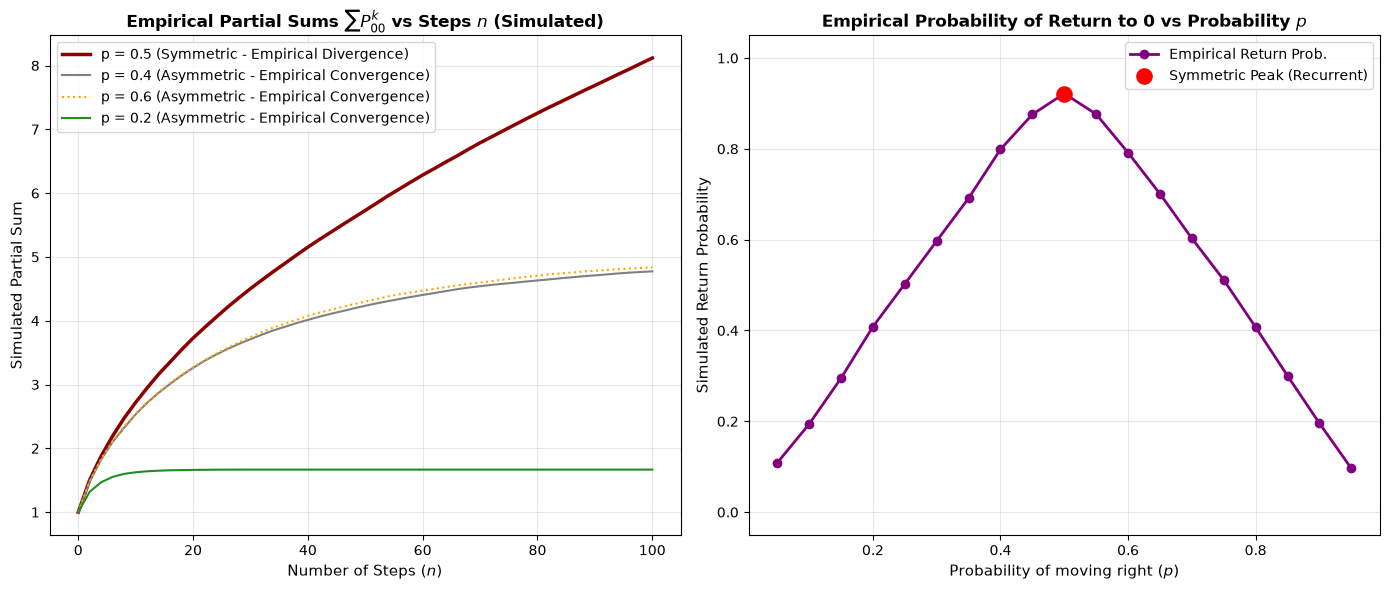

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Simulation Parameters
num_paths = 5000       # Number of random walks to simulate per p value
max_steps = 100        # Length of each random walk (n)
even_steps = np.arange(0, max_steps + 1, 2)

def simulate_random_walks(p, num_paths, max_steps):
    """
    Simulates random walks and returns:
    1. Estimated P_00^n for each step (empirical probability of being at 0 at step n)
    2. Empirical probability of ever returning to 0 during the walk
    """
    random_inputs = np.random.rand(num_paths, max_steps)
    steps = np.where(random_inputs < p, 1, -1)
    
    positions = np.hstack([np.zeros((num_paths, 1)), np.cumsum(steps, axis=1)])
    
    p_00_empirical = []
    for n in even_steps:
        at_zero_count = np.sum(positions[:, n] == 0)
        p_00_empirical.append(at_zero_count / num_paths)
    
    partial_sums = np.cumsum(p_00_empirical)
    
    returned_to_zero = np.any(positions[:, 2:] == 0, axis=1)
    return_probability = np.sum(returned_to_zero) / num_paths
    
    return partial_sums, return_probability

print("Running simulations for Plot 1...")
sums_symmetric, _ = simulate_random_walks(0.5, num_paths, max_steps)
sums_asymmetric_1, _ = simulate_random_walks(0.4, num_paths, max_steps)
sums_asymmetric_2, _ = simulate_random_walks(0.6, num_paths, max_steps)
sums_highly_asym, _ = simulate_random_walks(0.2, num_paths, max_steps)

ax1.plot(even_steps, sums_symmetric, label='p = 0.5 (Symmetric - Empirical Divergence)', color='darkred', linewidth=2.5)
ax1.plot(even_steps, sums_asymmetric_1, label='p = 0.4 (Asymmetric - Empirical Convergence)', color='gray', linestyle='-')
ax1.plot(even_steps, sums_asymmetric_2, label='p = 0.6 (Asymmetric - Empirical Convergence)', color='orange', linestyle=':')
ax1.plot(even_steps, sums_highly_asym, label='p = 0.2 (Asymmetric - Empirical Convergence)', color='forestgreen')

ax1.set_title(r'Empirical Partial Sums $\sum P_{00}^k$ vs Steps $n$ (Simulated)', fontsize=12, fontweight='bold')
ax1.set_xlabel(r'Number of Steps ($n$)', fontsize=11)
ax1.set_ylabel('Simulated Partial Sum', fontsize=11)
ax1.legend(frameon=True, facecolor='white')
ax1.grid(True, alpha=0.3)


print("Running simulations for Plot 2 (this may take a few seconds)...")
p_range = np.linspace(0.05, 0.95, 19)  # Test 19 different values of p
empirical_returns = []

for p in p_range:
    _, ret_prob = simulate_random_walks(p, num_paths, max_steps)
    empirical_returns.append(ret_prob)

ax2.plot(p_range, empirical_returns, 'o-', color='purple', linewidth=2, label='Empirical Return Prob.')
ax2.scatter(0.5, empirical_returns[len(p_range)//2], color='red', s=120, zorder=5, label='Symmetric Peak (Recurrent)')

ax2.set_title(r'Empirical Probability of Return to 0 vs Probability $p$', fontsize=12, fontweight='bold')
ax2.set_xlabel(r'Probability of moving right ($p$)', fontsize=11)
ax2.set_ylabel('Simulated Return Probability', fontsize=11)
ax2.set_ylim(-0.05, 1.05)
ax2.legend(frameon=True, facecolor='white')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
print("Done! Displaying plots.")

plt.savefig(f'{FIG_DIR}/ret_probs_simulation.pdf', format='pdf')
plt.show()

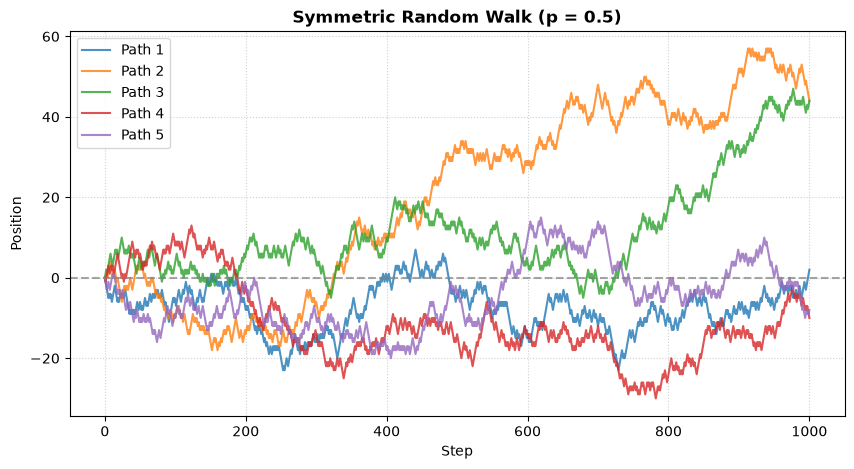

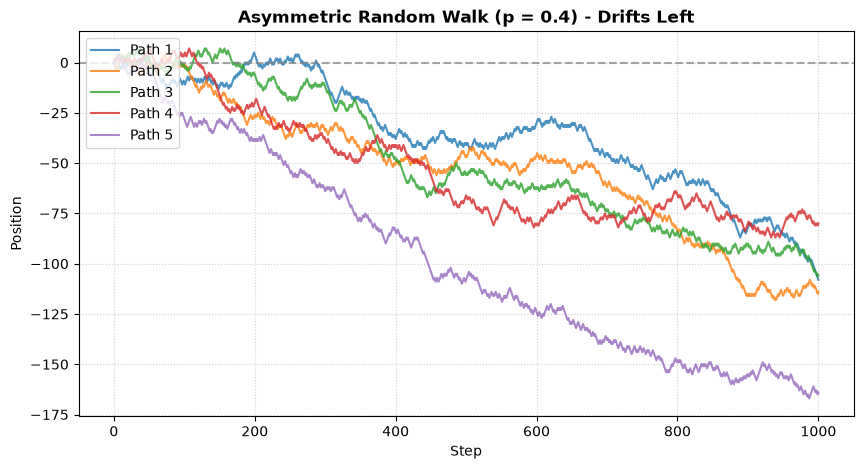

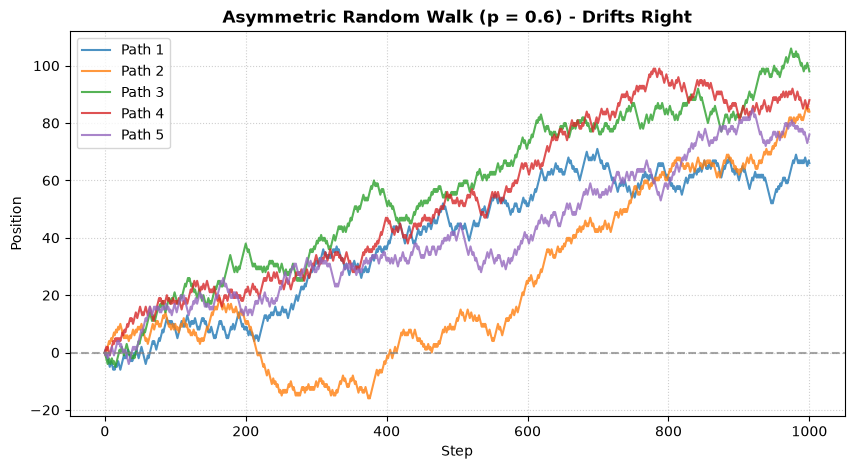

In [6]:
N = 1000
num_paths = 5
p_values = [0.5, 0.45, 0.55]
titles = [
    "Symmetric Random Walk (p = 0.5)",
    "Asymmetric Random Walk (p = 0.4) - Drifts Left",
    "Asymmetric Random Walk (p = 0.6) - Drifts Right"
]

# Generate and plot each case separately
for p, title in zip(p_values, titles):
    plt.figure(figsize=(10, 5))
    
    # Generate and plot 5 independent paths
    for i in range(num_paths):
        moves = np.where(np.random.rand(N) < p, 1, -1)
        path = np.concatenate([[0], np.cumsum(moves)])
        plt.plot(path, alpha=0.8, linewidth=1.5, label=f"Path {i+1}")
    
    # Baseline at zero
    plt.axhline(0, linestyle='--', c='gray', alpha=0.7)
    
    # Layout adjustments
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel("Step")
    plt.ylabel("Position")
    plt.legend(loc="upper left", frameon=True, facecolor='white')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Save each plot uniquely
    safe_title = title.split(" - ")[0].replace(" ", "_").replace("=", "").replace("(", "").replace(")", "").lower()
    plt.savefig(f'{FIG_DIR}/{safe_title}_paths.pdf', format='pdf')
    
    plt.show()

## Random walk with barriers
$p(0) = 0, p(N)=1$ boundary condition.

In [7]:
N = 20
num_paths = 10000

wins = np.zeros(N + 1)

for x in range(N + 1):
    pos = np.full(num_paths, x, dtype=int)
    active = (pos > 0) & (pos < N)

    while np.any(active):
        pos[active] += np.where(
            np.random.random(active.sum()) > 0.5,
            1,
            -1
        )
        active = (pos > 0) & (pos < N)

    wins[x] = np.sum(pos == N)

wins /= num_paths

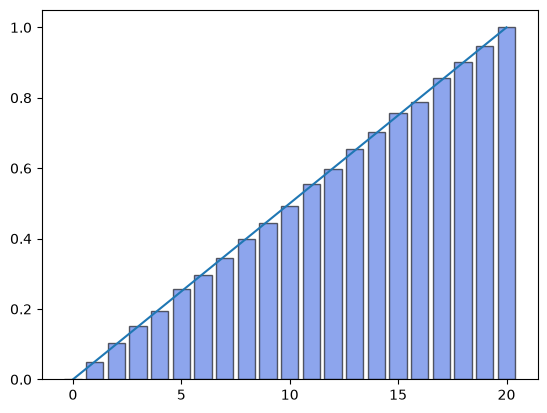

In [8]:
grid_sim = np.arange(0, N + 1)
plt.bar(grid_sim, wins, alpha=0.6, color='royalblue', edgecolor='black')
plt.plot(grid_sim, grid_sim / N)
plt.show()

$p(0) = a, p(N) = b$ boundary condition

In [9]:
N = 20
num_paths = 10000

a = 0.3
b = 0.8

p = np.zeros(N + 1)

for x in range(N + 1):
    pos = np.full(num_paths, x, dtype=int)
    active = (pos > 0) & (pos < N)

    while np.any(active):
        pos[active] += np.where(
            np.random.random(active.sum()) > 0.5,
            1,
            -1
        )
        active = (pos > 0) & (pos < N)

    rewards = np.where(pos == N, b, a)
    p[x] = rewards.mean()

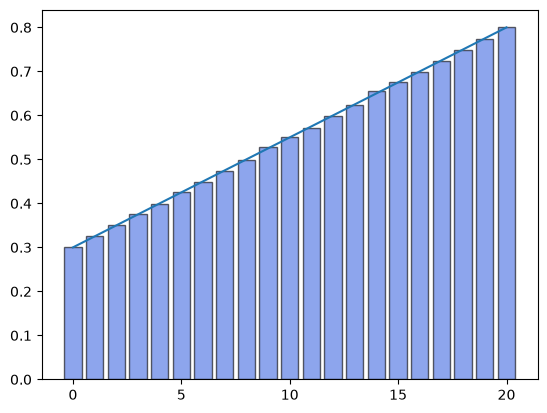

In [10]:
grid_sim = np.arange(0, N + 1)
plt.bar(grid_sim, p, alpha=0.6, color='royalblue', edgecolor='black')
plt.plot(grid_sim, a + grid_sim * (b - a) / N)
plt.show()

## Heat equation

### One-dimensional

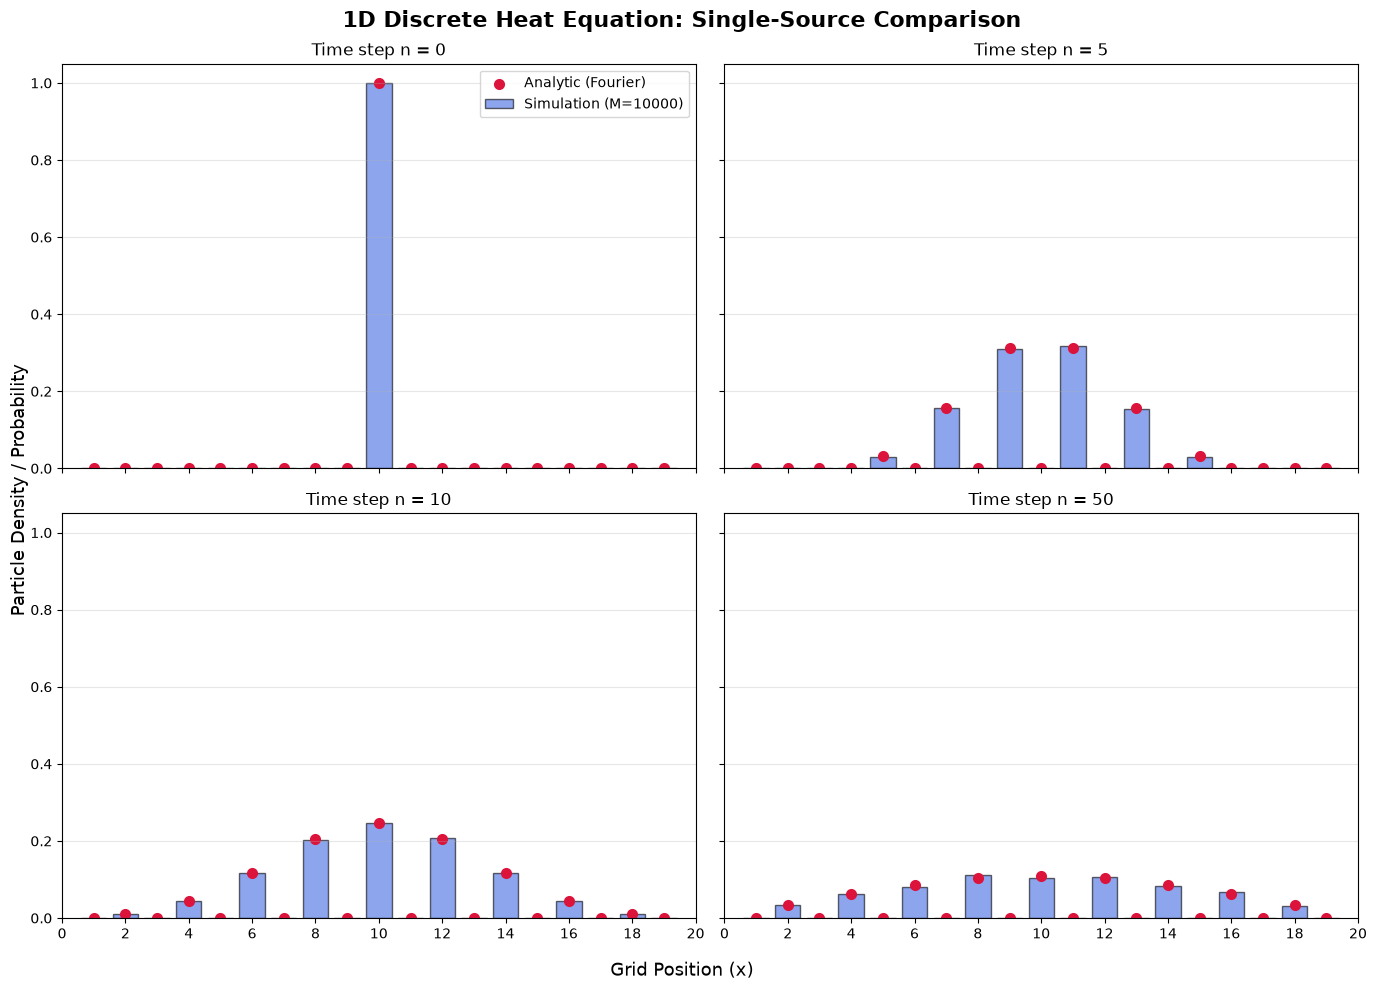

In [11]:
def simulate_random_walk(N, M, x0, time_steps):
    """
    Simulates M heat particles performing a random walk on a 1D grid.
    Boundaries at 0 and N are absorbing (temperature = 0).
    """
    positions = np.full(M, x0)
    
    for _ in range(time_steps):
        active_mask = (positions > 0) & (positions < N)
        
        random_steps = np.random.choice([-1, 1], size=np.count_nonzero(active_mask))
        
        positions[active_mask] += random_steps
        
    grid = np.arange(1, N)
    counts = np.array([np.count_nonzero(positions == y) for y in grid])
    
    density = counts / M
    
    return grid, density

def analytic_fourier(N, x0, time_steps):
    """
    Calculates the exact theoretical probability distribution 
    using the discrete Fourier series solution.
    """
    grid = np.arange(1, N)
    p_n = np.zeros_like(grid, dtype=float)
    
    for j in range(1, N):
        term1 = np.sin(np.pi * j * x0 / N)
        term2 = (np.cos(j * np.pi / N))**time_steps
        term3 = np.sin(np.pi * j * grid / N)
        
        p_n += term1 * term2 * term3
        
    p_n *= (2.0 / N)
    return grid, p_n


N = 20
M = 10000
x0 = 10
time_steps_vals = [0, 5, 10, 50]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, time_steps in enumerate(time_steps_vals):
    grid_sim, density_sim = simulate_random_walk(N, M, x0, time_steps)
    grid_ana, density_ana = analytic_fourier(N, x0, time_steps)

    ax = axes[i]
    ax.bar(grid_sim, density_sim, alpha=0.6, color='royalblue', edgecolor='black', label=f'Simulation (M={M})')
    ax.scatter(grid_ana, density_ana, marker='o', color='crimson', linewidth=2, label='Analytic (Fourier)')

    ax.set_title(f'Time step n = {time_steps}', fontsize=12)
    ax.set_xlim(0, N)
    ax.set_xticks(np.arange(0, N+1, 2))
    ax.grid(True, axis='y', alpha=0.3)
    
    if i == 0:
        ax.legend(fontsize=10)

# Set common labels for the entire figure
fig.suptitle('1D Discrete Heat Equation: Single-Source Comparison', fontsize=16, fontweight='bold')
fig.supxlabel('Grid Position (x)', fontsize=13)
fig.supylabel('Particle Density / Probability', fontsize=13)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/heat_1d_single_source.pdf', format='pdf')
plt.show()

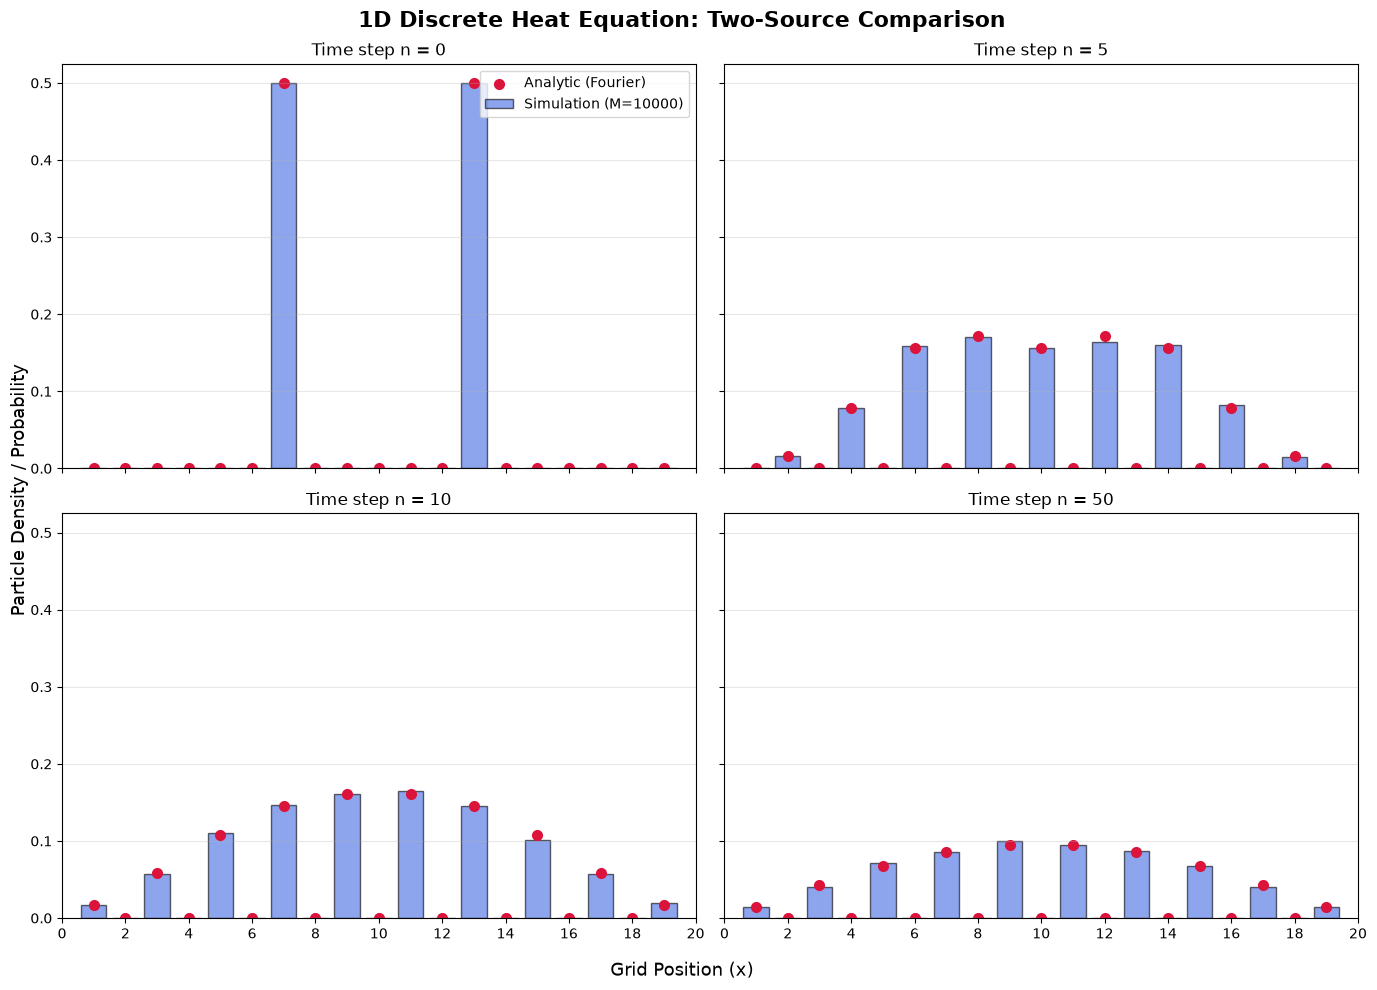

In [12]:
def simulate_random_walk2(N, M, x1, x2, time_steps):
    """
    Simulates M heat particles performing a random walk on a 1D grid.
    Boundaries at 0 and N are absorbing (temperature = 0).
    """
    positions = np.concatenate([
        np.full(M // 2, x1),
        np.full(M // 2, x2)
    ])
    
    for _ in range(time_steps):
        active_mask = (positions > 0) & (positions < N)
        
        random_steps = np.random.choice([-1, 1], size=np.count_nonzero(active_mask))
        
        positions[active_mask] += random_steps
        
    grid = np.arange(1, N)
    counts = np.array([np.count_nonzero(positions == y) for y in grid])
    
    density = counts / M
    
    return grid, density

def analytic_fourier2(N, x1, x2, time_steps):
    """
    Calculates the exact theoretical probability distribution 
    using the discrete Fourier series solution.
    """
    grid = np.arange(1, N)
    p_n = np.zeros_like(grid, dtype=float)
    
    for j in range(1, N):
        term1 = np.sin(np.pi * j * x1 / N) + np.sin(np.pi * j * x2 / N)
        term2 = (np.cos(j * np.pi / N))**time_steps
        term3 = np.sin(np.pi * j * grid / N)
        
        p_n += term1 * term2 * term3
        
    p_n *= (1.0 / N)
    return grid, p_n


N = 20
M = 10000
x1 = 7
x2 = 13
time_steps_vals = [0, 5, 10, 50]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, time_steps in enumerate(time_steps_vals):
    grid_sim, density_sim = simulate_random_walk2(N, M, x1, x2, time_steps)
    grid_ana, density_ana = analytic_fourier2(N, x1, x2, time_steps)

    ax = axes[i]

    ax.bar(grid_sim, density_sim, alpha=0.6, color='royalblue', edgecolor='black', label=f'Simulation (M={M})')
    ax.scatter(grid_ana, density_ana, marker='o', color='crimson', linewidth=2, label='Analytic (Fourier)')

    ax.set_title(f'Time step n = {time_steps}', fontsize=12)
    ax.set_xlim(0, N)
    ax.set_xticks(np.arange(0, N+1, 2))
    ax.grid(True, axis='y', alpha=0.3)

    if i == 0:
        ax.legend(fontsize=10)

fig.suptitle('1D Discrete Heat Equation: Two-Source Comparison', fontsize=16, fontweight='bold')
fig.supxlabel('Grid Position (x)', fontsize=13)
fig.supylabel('Particle Density / Probability', fontsize=13)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/heat_1d_two_source.pdf', format='pdf')
plt.show()

### Two-dimensional

In [13]:
def simulate_random_walk_2d(N1, N2, M, start_pos, time_steps):
    positions = np.full((M, 2), start_pos)
    
    for _ in range(time_steps):
        active = (positions[:,0] > 0) & (positions[:,0] < N1) & \
                 (positions[:,1] > 0) & (positions[:,1] < N2)
        
        moves = np.random.choice([0, 1, 2, 3], size=np.count_nonzero(active))
        
        positions[active, 0] += np.where(moves == 2, -1, np.where(moves == 3, 1, 0))
        positions[active, 1] += np.where(moves == 0, 1, np.where(moves == 1, -1, 0))
        
    density = np.zeros((N1 + 1, N2 + 1))
    for i in range(M):
        p = positions[i]
        if 0 < p[0] < N1 and 0 < p[1] < N2:
            density[p[0], p[1]] += 1
            
    return density / M

def analytic_fourier_2d(N1, N2, start_pos, time_steps):
    x0_1, x0_2 = start_pos
    grid1, grid2 = np.meshgrid(np.arange(1, N1), np.arange(1, N2), indexing='ij')
    
    p_n = np.zeros((N1 - 1, N2 - 1))
    
    for k1 in range(1, N1):
        for k2 in range(1, N2):
            lambda_k = 0.5 * np.cos(k1 * np.pi / N1) + 0.5 * np.cos(k2 * np.pi / N2)
            
            coeff = (4.0 / (N1 * N2)) * np.sin(k1 * np.pi * x0_1 / N1) * np.sin(k2 * np.pi * x0_2 / N2)
            mode = np.sin(k1 * np.pi * grid1 / N1) * np.sin(k2 * np.pi * grid2 / N2)
            
            p_n += coeff * (lambda_k ** time_steps) * mode
            
    return p_n

In [14]:
def plot_2d_heatmaps_with_error(sim_density, ana_density, time_steps):
    # Align the shapes: extract only the interior grid from the simulation
    # sim_density is (N1+1, N2+1), we slice it to match ana_density which is (N1-1, N2-1)
    N1, N2 = ana_density.shape[0] + 1, ana_density.shape[1] + 1
    sim_interior = sim_density[1:N1, 1:N2]

    error_matrix = sim_interior - ana_density
    error_matrix[np.abs(error_matrix) < 1e-12] = 0.0
    
    mae = np.mean(np.abs(error_matrix))  # Mean Absolute Error
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    vmax_val = max(np.max(sim_interior), np.max(ana_density))
    
    sns.heatmap(sim_interior, ax=axes[0], cmap='hot', vmin=0, vmax=vmax_val, cbar_kws={'label': 'Density'})
    axes[0].set_title(f"Simulation (t={time_steps})")
    axes[0].invert_yaxis()
    
    sns.heatmap(ana_density, ax=axes[1], cmap='hot', vmin=0, vmax=vmax_val, cbar_kws={'label': 'Density'})
    axes[1].set_title("Analytic Fourier")
    axes[1].invert_yaxis()
    
    max_err = np.max(np.abs(error_matrix))
    if max_err == 0: max_err = 1e-5
    
    sns.heatmap(error_matrix, ax=axes[2], cmap='coolwarm', vmin=-max_err, vmax=max_err, cbar_kws={'label': 'Difference'})
    axes[2].set_title(f"Error Map (Mean Abs Error: {mae:.6f})")
    axes[2].invert_yaxis()
    
    plt.tight_layout()

    plt.savefig(f'{FIG_DIR}/heat_2d_single_source_{time_steps}.pdf', format='pdf')
    plt.show()

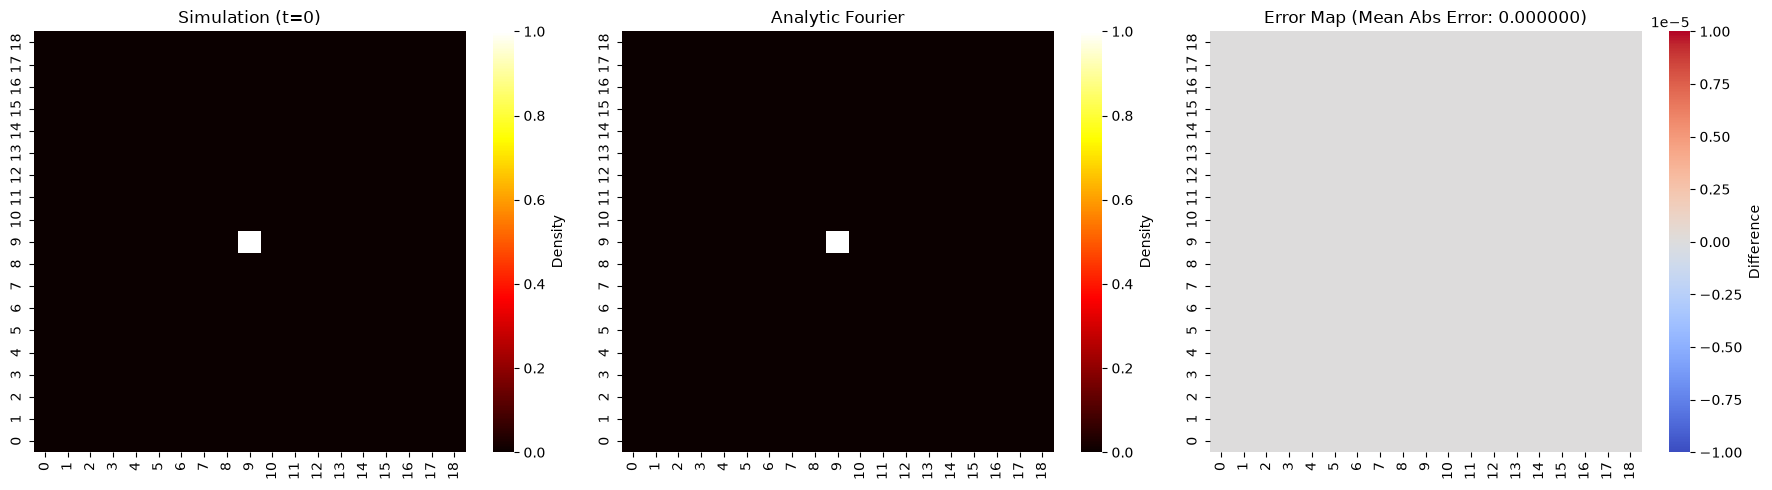

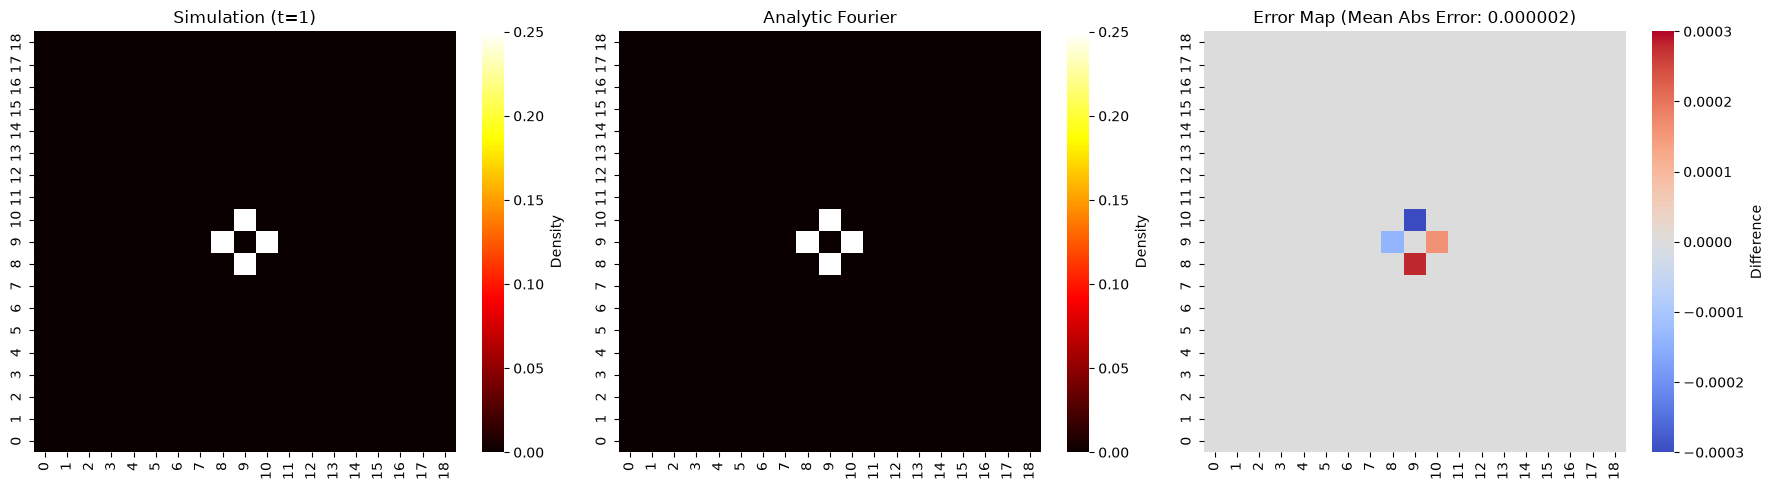

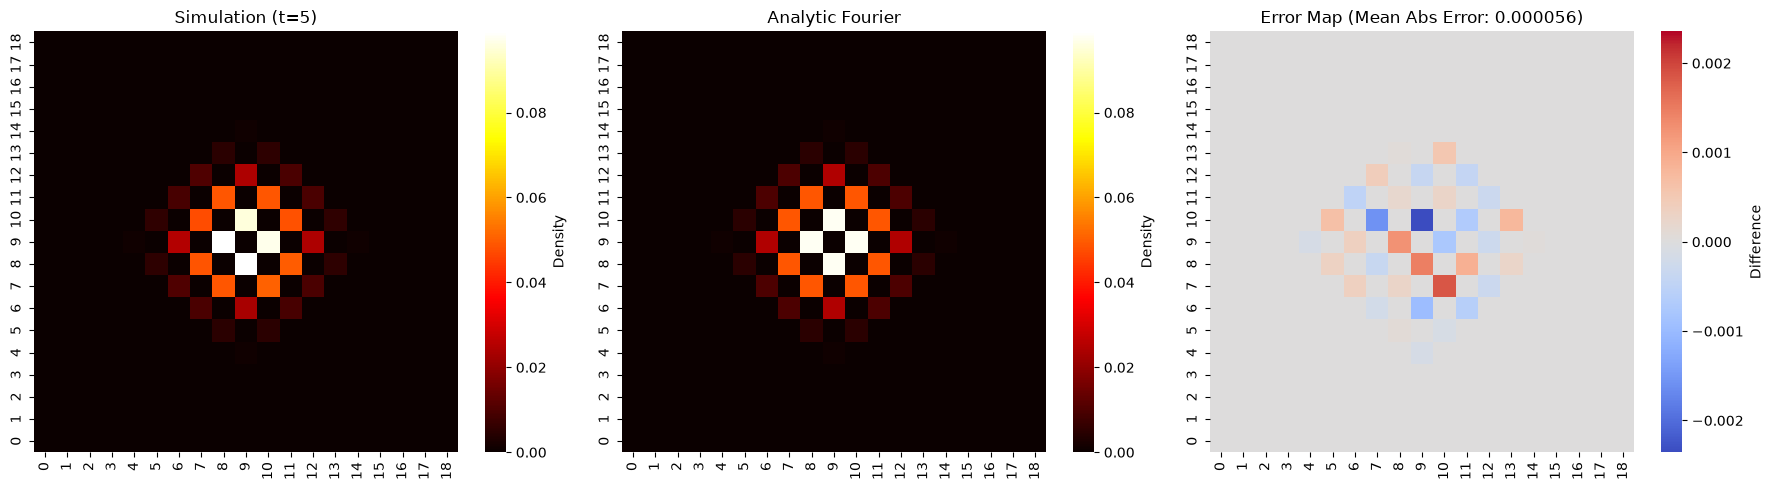

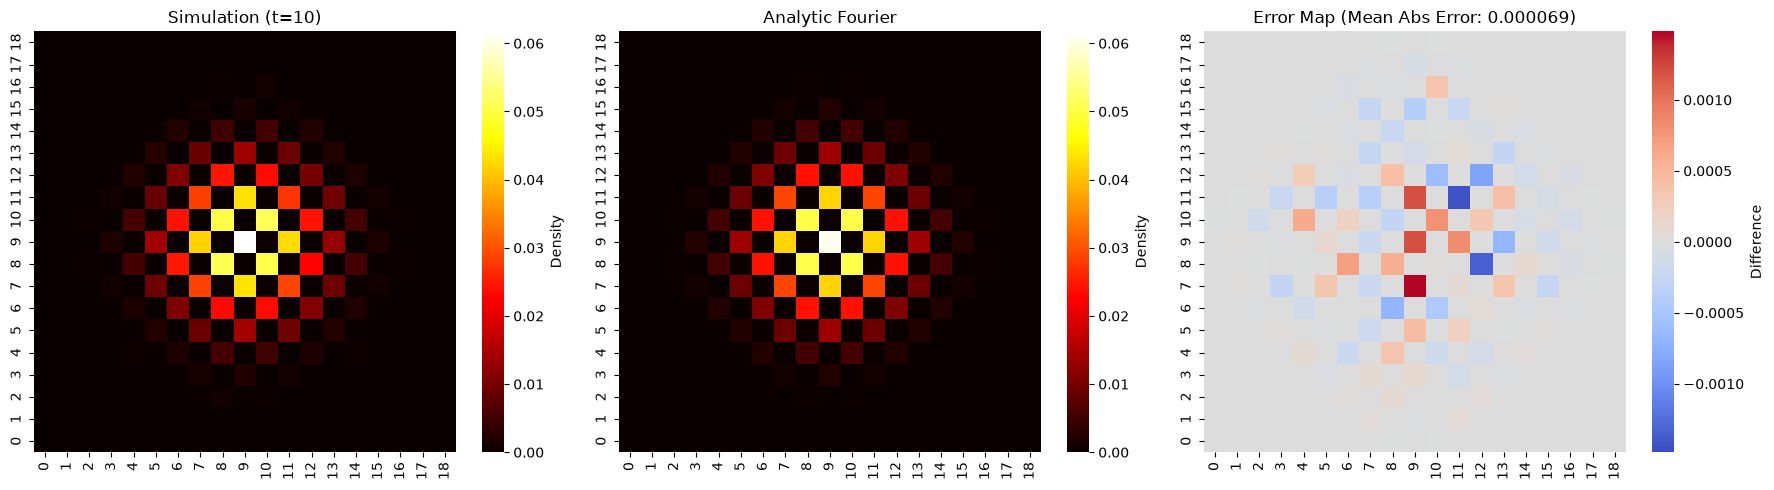

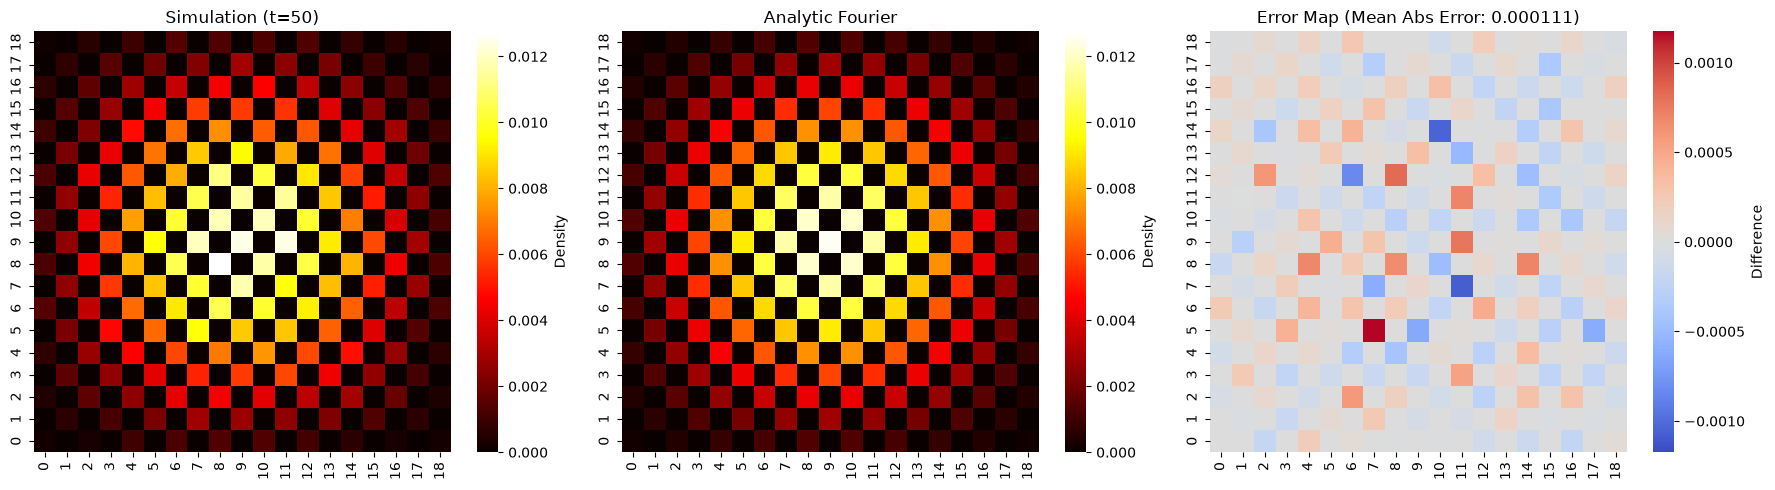

In [15]:
N1, N2 = 20, 20
M = 50_000
start_pos = (10, 10)
time_steps_vals = [0, 1, 5, 10, 50]

for time_steps in time_steps_vals:
    sim_density = simulate_random_walk_2d(N1, N2, M, start_pos, time_steps)
    ana_density = analytic_fourier_2d(N1, N2, start_pos, time_steps)

    plot_2d_heatmaps_with_error(sim_density, ana_density, time_steps)

In [16]:
def simulate_random_walk_2d_smiley(N1, N2, M, time_steps):
    cx, cy = N1 // 2, N2 // 2
    R = min(N1, N2) // 4

    smiley_points = []

    # Face outline
    for x in range(N1 + 1):
        for y in range(N2 + 1):
            r = np.sqrt((x - cx)**2 + (y - cy)**2)
            if abs(r - R) < 1.5:
                smiley_points.append((x, y))

    # Eyes
    eye_r = max(1, R // 8)

    left_eye = (cx - R // 3, cy + R // 3)
    right_eye = (cx + R // 3, cy + R // 3)

    for x in range(N1 + 1):
        for y in range(N2 + 1):
            if (x - left_eye[0])**2 + (y - left_eye[1])**2 <= eye_r**2:
                smiley_points.append((x, y))
            if (x - right_eye[0])**2 + (y - right_eye[1])**2 <= eye_r**2:
                smiley_points.append((x, y))

    # Smile (lower arc)
    for theta in np.linspace(np.pi/6, 5*np.pi/6, 100):
        x = int(round(cx + 0.6 * R * np.cos(theta)))
        y = int(round(cy - 0.4 * R * np.sin(theta)))
        smiley_points.append((x, y))

    smiley_points = np.array(list(set(smiley_points)))

    idx = np.random.choice(len(smiley_points), size=M, replace=True)
    positions = smiley_points[idx].copy()

    for _ in range(time_steps):
        active = (
            (positions[:, 0] > 0) & (positions[:, 0] < N1) &
            (positions[:, 1] > 0) & (positions[:, 1] < N2)
        )

        moves = np.random.choice([0, 1, 2, 3], size=np.count_nonzero(active))

        positions[active, 0] += np.where(
            moves == 2, -1,
            np.where(moves == 3, 1, 0)
        )

        positions[active, 1] += np.where(
            moves == 0, 1,
            np.where(moves == 1, -1, 0)
        )

    density = np.zeros((N1 + 1, N2 + 1))

    for p in positions:
        if 0 < p[0] < N1 and 0 < p[1] < N2:
            density[p[0], p[1]] += 1

    return density / M

In [17]:
def plot_2x2_heatmaps(N1, N2, M, time_steps_vals, simulate_fn, analytic_fn=None):
    """
    Plots a 2x2 grid of 2D heatmaps for 4 distinct time steps.
    If analytic_fn is provided, it plots the Analytic solution; 
    otherwise, it plots the Simulation.
    """
    if len(time_steps_vals) != 4:
        raise ValueError("This function specifically expects exactly 4 time steps for a 2x2 grid.")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
    axes = axes.flatten()
    
    use_analytic = (analytic_fn is not None)
    mode_title = "Analytic Fourier" if use_analytic else "Simulation"
    
    grids = []
    for t in time_steps_vals:
        data = analytic_fn(N1, N2, t) if use_analytic else simulate_fn(N1, N2, M, t)
        grids.append(data)
    vmax_val = max(np.max(g) for g in grids)

    # 3. Populate the 2x2 grid
    for i, t in enumerate(time_steps_vals):
        ax = axes[i]
        density_matrix = grids[i]
        
        sns.heatmap(
            density_matrix.T, 
            cmap="hot", 
            vmin=0, 
            vmax=vmax_val, 
            ax=ax,
            cbar_kws={"label": "Probability Density"} if i == 1 else None # Label just one cbar to keep it clean
        )
        
        ax.set_title(f"{mode_title} (t={t})", fontsize=12, fontweight='bold')
        ax.invert_yaxis()
        
        if i in [2, 3]:
            ax.set_xlabel("X1 Position", fontsize=11)
        if i in [0, 2]:
            ax.set_ylabel("X2 Position", fontsize=11)

    fig.suptitle(f"2D Heat Diffusion Progression ({mode_title})", fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()

    plt.savefig(f'{FIG_DIR}/heat_2d_smiley.pdf', format='pdf')
    plt.show()

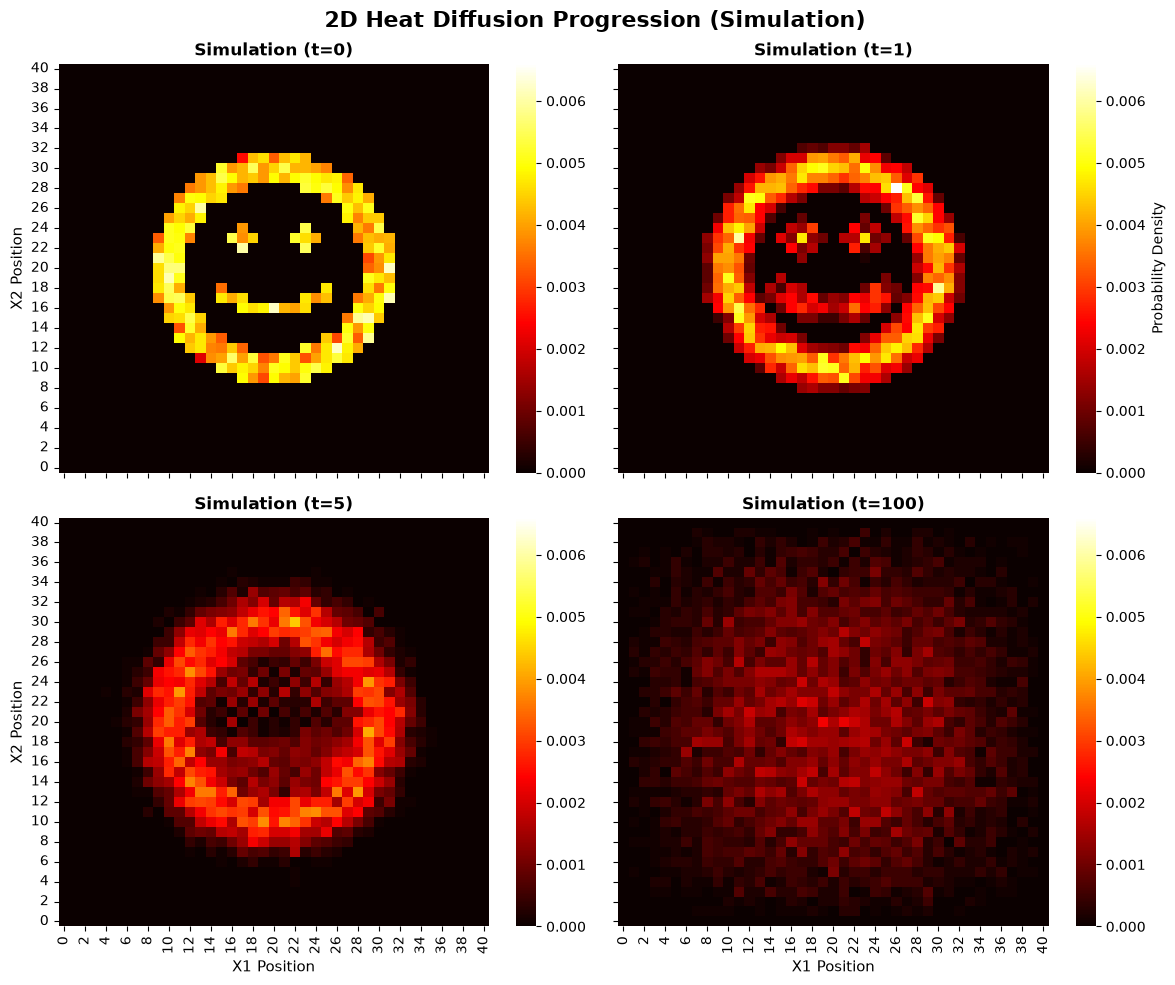

In [18]:
N1 = 40
N2 = 40
M = 10000
time_steps_vals = [0, 1, 5, 100]


plot_2x2_heatmaps(
    N1=N1, 
    N2=N2, 
    M=M, 
    time_steps_vals=time_steps_vals, 
    simulate_fn=simulate_random_walk_2d_smiley,
    analytic_fn=None
)